<a href="https://colab.research.google.com/github/amrios80/MINE_4206_AML_202610/blob/main/labs/lab_2/MINE_4206_AML_Taller2_Adriana_Rios_Johana_Rios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Logo AML](https://github.com/nicolastibata/MINE_4206_AML_202610/blob/main/docs/logo.jpg?raw=true)

# **Laboratorio 2 - Sesión 2: SVM**
**Tutor: Nicolás Tibatá**

## **Tabla de Contenido**

[Contexto y objetivos](#scrollTo=kgcjzQ76ODRS)<br>
[1. Introducción de los datos](#scrollTo=2dNwUTBZO8OE)<br>
[2. Preparación y Modelamiento](#scrollTo=SlV42CI6PBoQ)<br>
[3. Preguntas](#scrollTo=OCwUBTvxPRdS)<br>

### **Contexto y Objetivos**

Este dataset tiene como objetivo analizar la sostenibilidad en el sector de la vivienda. Consta de 1,640 registros y 19 columnas que integran datos sobre emisiones operativas y embebidas (las generadas durante la fabricación de materiales). El objetivo principal es evaluar cómo factores clave como las certificaciones ecológicas, las intervenciones políticas y la gestión de la cadena de suministro impactan directamente en la huella de carbono de los proyectos de construcción.

- Construir y evaluar un modelo SVM.
- Entender las métricas de evaluación y los AUC scores.

**Datos:** [CarbonReduction](https://www.kaggle.com/datasets/programmer3/carbon-reduction-in-residential-construction)

**Diccionario**
| Columna | Descripción |
| :--- | :--- |
| **Project_ID** | Identificador único para cada proyecto de construcción residencial. |
| **Project_Type** | Clasificación del edificio (ej. de baja altura, media altura o gran altura). |
| **Building_Area_m2** | Área total de construcción del proyecto medida en metros cuadrados. |
| **Green_Certification_Level** | Nivel de certificación ambiental alcanzado (Platinum, Gold, Silver, Basic, None). |
| **Policy_Interventions** | Índice que representa la intensidad de las medidas políticas aplicadas para reducir el carbono. |
| **Lifecycle_Phase** | Fase específica del ciclo de vida evaluada (Producción de materiales, Construcción, Operación, Fin de vida). |
| **Embodied_Emissions_tCO2e** | Emisiones por fabricación, transporte e instalación de materiales (toneladas de CO2e). |
| **Operational_Emissions_tCO2e** | Emisiones por el uso diario (calefacción, electricidad, etc.) (toneladas de CO2e). |
| **Supply_Chain_Emission_Share_%** | Porcentaje de las emisiones totales que provienen de la cadena de suministro. |
| **ReadyMix_Concrete_Emission_tCO2e** | Emisiones de carbono derivadas específicamente del suministro de concreto premezclado. |
| **Electric_Power_Generation_Emission_tCO2e** | Emisiones por la generación de electricidad usada durante el ciclo de vida. |
| **Lighting_Fixtures_Emission_tCO2e** | Emisiones asociadas a la producción y suministro de sistemas de iluminación. |
| **Material_Reuse_%** | Porcentaje de materiales de construcción que provienen de fuentes recicladas o reutilizadas. |
| **Renewable_Energy_Share_%** | Porcentaje de energía requerida que se cubre con fuentes renovables (solar, eólica, etc.). |
| **Waste_Minimization_%** | Porcentaje de residuos de construcción que se desvían de los vertederos. |
| ** Urban Sustainability_Score** | Métrica compuesta (0-100) que evalúa la sostenibilidad ambiental y urbana global. |
| **Emission_Reduction_Class** | **Columna Objetivo**: Clasifica el éxito de reducción en Bajo (Low), Medio (Medium) o Alto (High). |

### **1. Introducción a los datos**

In [ ]:
# Importamos o instalamos librerias necesarias
!pip install ydata-profiling -q
from ydata_profiling import ProfileReport
# Acceso a credenciales
import os
from google.colab import files
from google.colab import userdata
# Manejo de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Modelamiento
import sklearn
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,  OneHotEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler, label_binarize
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, roc_curve, auc, roc_auc_score
#Librerías extras
import itertools
from datetime import datetime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.4/400.4 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 1.6 MB/s eta 0:00:00


Cargamos los datos directamente de kaggle con las credenciales personales, pueden consultar cómo funciona [acá](https://www.kaggle.com/discussions/general/74235#2580958).

In [ ]:
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')

!kaggle datasets download -d programmer3/carbon-reduction-in-residential-construction
!unzip "carbon-reduction-in-residential-construction.zip"

Dataset URL: https://www.kaggle.com/datasets/programmer3/carbon-reduction-in-residential-construction
License(s): CC0-1.0
  0% 0.00/70.6k [00:00<?, ?B/s]
100% 70.6k/70.6k [00:00<00:00, 153MB/s]
Archive:  carbon-reduction-in-residential-construction.zip
  inflating: Policy_Driven_Carbon_Reduction_1640.csv  


In [ ]:
data = pd.read_csv('Policy_Driven_Carbon_Reduction_1640.csv')
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1640 entries, 0 to 1639
Data columns (total 19 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Project_ID                        1640 non-null   object 
 1   Project_Type                      1640 non-null   object 
 2   Building_Area_m2                  1640 non-null   int64  
 3   Green_Certification_Level         1320 non-null   object 
 4   Policy_Interventions              1640 non-null   int64  
 5   Lifecycle_Phase                   1640 non-null   object 
 6   Embodied_Emissions_tCO2e          1640 non-null   float64
 7   Operational_Emissions_tCO2e       1640 non-null   float64
 8   Supply_Chain_Emission_Share_%     1640 non-null   float64
 9   ReadyMix_Concrete_Emission_tCO2e  1640 non-null   float64
 10  Electric_Power_Emission_tCO2e     1640 non-null   float64
 11  Lighting_Fixture_Emission_tCO2e   1640 non-null   float64
 12  Materi

,Building_Area_m2,Policy_Interventions,Embodied_Emissions_tCO2e,Operational_Emissions_tCO2e,Supply_Chain_Emission_Share_%,ReadyMix_Concrete_Emission_tCO2e,Electric_Power_Emission_tCO2e,Lighting_Fixture_Emission_tCO2e,Material_Reuse_%,Renewable_Energy_%,Waste_Minimization_%,Urban_Sustainability_Score,Total_Lifecycle_Emissions_tCO2e,Emission_Reduction_%
count,1640.000000,1640.000000,1640.000000,1640.000000,1640.000000,1640.000000,1640.000000,1640.000000,1640.000000,1640.000000,1640.000000,1640.000000,1640.000000,1640.000000
mean,10312.521951,1.960976,1073.873866,1632.026372,55.257622,548.699957,797.849030,159.191116,25.681890,35.881890,20.262134,59.028598,2705.900238,26.189573
std,5627.477838,1.414106,515.000760,757.602387,14.389729,264.565731,410.727225,81.079699,14.094244,20.319337,11.555985,21.817457,926.772210,12.613638
min,511.000000,0.000000,200.430000,300.140000,30.000000,100.140000,101.870000,20.090000,0.000000,0.000000,0.100000,20.000000,578.380000,2.000000
25%,5554.750000,1.000000,632.937500,991.045000,42.775000,315.622500,434.992500,89.205000,14.000000,18.275000,10.575000,40.775000,2042.750000,16.300000
50%,10380.500000,2.000000,1056.275000,1633.580000,55.300000,541.995000,785.610000,158.840000,26.300000,35.750000,20.300000,60.400000,2692.595000,25.550000
75%,15223.250000,3.000000,1512.135000,2276.110000,67.800000,783.280000,1171.167500,230.037500,37.300000,53.025000,30.325000,77.900000,3386.572500,36.300000
max,19981.000000,4.000000,1998.570000,2996.270000,80.000000,999.400000,1497.620000,299.980000,50.000000,70.000000,40.000000,95.000000,4921.800000,55.000000


In [ ]:
data

,Project_ID,Project_Type,Building_Area_m2,Green_Certification_Level,Policy_Interventions,Lifecycle_Phase,Embodied_Emissions_tCO2e,Operational_Emissions_tCO2e,Supply_Chain_Emission_Share_%,ReadyMix_Concrete_Emission_tCO2e,Electric_Power_Emission_tCO2e,Lighting_Fixture_Emission_tCO2e,Material_Reuse_%,Renewable_Energy_%,Waste_Minimization_%,Urban_Sustainability_Score,Total_Lifecycle_Emissions_tCO2e,Emission_Reduction_%,Emission_Reduction_Class
0,P0001,High-rise,8702,Silver,2,Operation,956.45,725.68,55.2,534.28,383.47,38.27,45.0,65.4,15.2,87.9,1682.13,24.8,Medium
1,P0002,Low-rise,2368,Basic,2,Construction,1211.80,769.83,62.3,946.28,1035.56,260.64,16.1,10.3,2.5,50.3,1981.63,19.8,Medium
2,P0003,High-rise,15061,Platinum,2,Operation,210.56,2354.05,78.6,364.31,355.47,263.17,32.6,56.7,2.6,37.3,2564.61,44.3,High
3,P0004,High-rise,16012,Platinum,0,Operation,341.32,342.76,32.8,474.13,958.84,152.18,35.4,57.6,1.7,37.5,684.08,38.3,High
4,P0005,Low-rise,15399,Gold,0,End-of-life,1786.26,1806.09,58.7,808.26,676.74,163.98,38.9,49.6,16.4,69.7,3592.35,28.2,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1635,P1636,Low-rise,16712,Basic,0,Material Production,1395.33,611.58,38.3,194.45,1396.72,266.21,42.2,6.7,27.9,23.4,2006.91,8.3,Low
1636,P1637,High-rise,19451,Gold,3,Material Production,659.16,1398.39,50.1,120.11,594.42,270.86,33.7,35.2,21.2,28.0,2057.55,36.6,High
1637,P1638,Mid-rise,1807,Platinum,3,Construction,428.66,2589.52,47.2,254.36,742.22,86.83,42.5,31.9,38.8,81.1,3018.18,45.4,High
1638,P1639,High-rise,15352,NaN,4,Material Production,305.37,1292.68,50.0,608.36,1474.16,75.79,6.9,28.7,36.1,66.8,1598.05,19.4,Medium


### **2. Preparación y Modelamiento**

Antes de preparar y modelar los datos, veamos un poco cómo se constituyen

In [ ]:
ProfileReport(data)

Hallazgos:
- Nuestra variable Target `Emission_Reduction_Class` no presenta un desbalance de clases significativo, sin embargo es recomendable usar `stratify` en la separación de los datos.
- Las variables numéricas no presentan sesgos significativos, pero la escala entre ellos si es variable, por lo tanto se puede aplicar un escalador.
- Las variables categoricas presentan balances equilibrados y requieren de `onehotencoder` para su codificación.
- `Green_Certification_Level` presenta ausencias en el 19% de sus datos, debido a que nuestro dataset no es tan grande imputamos los ausencias con la moda.
- `Project_ID` debe ser eliminado por ser un identificador. `Emission_Reduction_%`, `Total_Lifecycle_Emissions_tCO2e` por ser consecuentes o las causantes de la clsificación, si las dejamos nuestra clasificación será casi perfecta.

#### **Preparación**

In [ ]:
# 1. Separar los datos en entrenamiento y test -> SIEMPRE
train_data, test_data = train_test_split(data, test_size=0.2, random_state=71, stratify=data['Emission_Reduction_Class'])


In [ ]:
drop_variables = ['Project_ID', 'Emission_Reduction_%', 'Total_Lifecycle_Emissions_tCO2e']
target_feature = 'Emission_Reduction_Class'
categorical_features = ['Project_Type', 'Green_Certification_Level', 'Lifecycle_Phase']

def preprocess(df):
  print(f"Total de filas duplicadas eliminadas: {df.duplicated().sum().sum()}")
  df = df.drop_duplicates() # Eliminamos duplicados
  df = df.drop(drop_variables, axis = 1) # Eliminamos columnas que no vamos a usar
  X_data, y_variable = df.drop([target_feature], axis=1), df[target_feature] # Separamos nuestro target de las variables explicativas
  return X_data, y_variable


In [ ]:
X_train, y_train = preprocess(train_data)
display(X_train)
display(y_train)

Total de filas duplicadas eliminadas: 0


,Project_Type,Building_Area_m2,Green_Certification_Level,Policy_Interventions,Lifecycle_Phase,Embodied_Emissions_tCO2e,Operational_Emissions_tCO2e,Supply_Chain_Emission_Share_%,ReadyMix_Concrete_Emission_tCO2e,Electric_Power_Emission_tCO2e,Lighting_Fixture_Emission_tCO2e,Material_Reuse_%,Renewable_Energy_%,Waste_Minimization_%,Urban_Sustainability_Score
1278,High-rise,5128,Silver,4,Material Production,1089.22,803.06,50.0,941.73,957.74,62.48,42.6,38.2,19.3,94.9
318,Mid-rise,12503,NaN,0,Operation,844.79,2409.66,47.2,146.57,906.72,57.87,2.4,22.4,4.7,22.0
1547,Low-rise,7064,Platinum,3,Material Production,1515.99,955.33,68.2,583.60,359.80,140.32,16.2,69.9,27.6,27.1
902,Mid-rise,11017,Silver,3,End-of-life,269.05,1724.98,60.3,946.65,1240.71,211.81,29.8,9.1,34.4,47.1
1318,Low-rise,10912,Silver,1,Material Production,909.35,555.05,40.4,391.30,795.27,263.88,7.2,4.5,3.0,36.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436,High-rise,16004,NaN,4,End-of-life,878.26,1512.70,35.4,883.80,700.67,132.34,33.9,32.3,7.4,93.4
141,High-rise,12301,Gold,1,Material Production,377.38,2541.09,52.5,936.05,335.05,92.12,8.0,25.8,33.1,21.9
796,Low-rise,5219,NaN,0,Construction,871.77,1219.56,33.7,788.60,358.92,85.31,26.2,60.9,12.7,26.1
439,High-rise,12644,Basic,3,Operation,634.24,2240.23,61.0,519.28,1434.56,57.52,16.4,54.2,11.4,50.3


,Emission_Reduction_Class
1278,Medium
318,Low
1547,High
902,Medium
1318,Medium
...,...
436,Medium
141,Medium
796,Low
439,Medium


In [ ]:
# Definamos las variables numericas
num_features = list(set(X_train.columns) - set(categorical_features))
num_features

['Building_Area_m2',
 'Policy_Interventions',
 'ReadyMix_Concrete_Emission_tCO2e',
 'Urban_Sustainability_Score',
 'Supply_Chain_Emission_Share_%',
 'Material_Reuse_%',
 'Renewable_Energy_%',
 'Electric_Power_Emission_tCO2e',
 'Waste_Minimization_%',
 'Operational_Emissions_tCO2e',
 'Lighting_Fixture_Emission_tCO2e',
 'Embodied_Emissions_tCO2e']

In [ ]:
# Construimos y aplicamos nuestro pipeline
num_transformer = Pipeline(
    steps=[
        ('scaler', StandardScaler())
    ]
)

cat_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),  # moda
        ('scaler', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, make_column_selector(dtype_include=np.number)),
        ('cat', cat_transformer, make_column_selector(dtype_include=object))
    ]
).set_output(transform="pandas") #Para preservar los nombres de las columnas

pipe = Pipeline(steps=[('column_transformer', preprocessor)])

In [ ]:
pipe.fit_transform(X_train)

,num__Building_Area_m2,num__Policy_Interventions,num__Embodied_Emissions_tCO2e,num__Operational_Emissions_tCO2e,num__Supply_Chain_Emission_Share_%,num__ReadyMix_Concrete_Emission_tCO2e,num__Electric_Power_Emission_tCO2e,num__Lighting_Fixture_Emission_tCO2e,num__Material_Reuse_%,num__Renewable_Energy_%,...,cat__Project_Type_Low-rise,cat__Project_Type_Mid-rise,cat__Green_Certification_Level_Basic,cat__Green_Certification_Level_Gold,cat__Green_Certification_Level_Platinum,cat__Green_Certification_Level_Silver,cat__Lifecycle_Phase_Construction,cat__Lifecycle_Phase_End-of-life,cat__Lifecycle_Phase_Material Production,cat__Lifecycle_Phase_Operation
1278,-0.915989,1.452000,0.035990,-1.102177,-0.369756,1.499143,0.399668,-1.191308,1.195157,0.102723,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
318,0.392657,-1.390259,-0.439273,1.041816,-0.566317,-1.496617,0.274329,-1.248403,-1.649327,-0.672309,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1547,-0.572458,0.741435,0.865790,-0.898974,0.907891,0.149890,-1.069269,-0.227262,-0.672862,1.657692,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
902,0.128976,0.741435,-1.558726,0.128117,0.353308,1.517679,1.094830,0.658140,0.289451,-1.324710,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1318,0.110344,-0.679694,-0.313745,-1.433144,-1.043680,-0.574599,0.000534,1.303026,-1.309687,-1.550352,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436,1.013887,1.452000,-0.374195,-0.155169,-1.394682,1.280892,-0.231866,-0.326094,0.579560,-0.186688,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
141,0.356814,-0.679694,-1.348093,1.217208,-0.194255,1.477743,-1.130071,-0.824217,-1.253080,-0.505530,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
796,-0.899842,-1.390259,-0.386814,-0.546361,-1.514023,0.922226,-1.071431,-0.908559,0.034721,1.216218,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
439,0.417677,0.741435,-0.848661,0.815713,0.402448,-0.092435,1.571054,-1.252737,-0.658710,0.887565,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [ ]:
cat_column_names = pipe['column_transformer'].transformers_[1][1][1].get_feature_names_out()
num_column_names = pipe['column_transformer'].transformers_[0][1].feature_names_in_
col_names = list(num_column_names) + list(cat_column_names)

col_names

['Building_Area_m2',
 'Policy_Interventions',
 'Embodied_Emissions_tCO2e',
 'Operational_Emissions_tCO2e',
 'Supply_Chain_Emission_Share_%',
 'ReadyMix_Concrete_Emission_tCO2e',
 'Electric_Power_Emission_tCO2e',
 'Lighting_Fixture_Emission_tCO2e',
 'Material_Reuse_%',
 'Renewable_Energy_%',
 'Waste_Minimization_%',
 'Urban_Sustainability_Score',
 'Project_Type_High-rise',
 'Project_Type_Low-rise',
 'Project_Type_Mid-rise',
 'Green_Certification_Level_Basic',
 'Green_Certification_Level_Gold',
 'Green_Certification_Level_Platinum',
 'Green_Certification_Level_Silver',
 'Lifecycle_Phase_Construction',
 'Lifecycle_Phase_End-of-life',
 'Lifecycle_Phase_Material Production',
 'Lifecycle_Phase_Operation']

In [ ]:
pd.DataFrame(pipe.fit_transform(X_train))

,num__Building_Area_m2,num__Policy_Interventions,num__Embodied_Emissions_tCO2e,num__Operational_Emissions_tCO2e,num__Supply_Chain_Emission_Share_%,num__ReadyMix_Concrete_Emission_tCO2e,num__Electric_Power_Emission_tCO2e,num__Lighting_Fixture_Emission_tCO2e,num__Material_Reuse_%,num__Renewable_Energy_%,...,cat__Project_Type_Low-rise,cat__Project_Type_Mid-rise,cat__Green_Certification_Level_Basic,cat__Green_Certification_Level_Gold,cat__Green_Certification_Level_Platinum,cat__Green_Certification_Level_Silver,cat__Lifecycle_Phase_Construction,cat__Lifecycle_Phase_End-of-life,cat__Lifecycle_Phase_Material Production,cat__Lifecycle_Phase_Operation
1278,-0.915989,1.452000,0.035990,-1.102177,-0.369756,1.499143,0.399668,-1.191308,1.195157,0.102723,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
318,0.392657,-1.390259,-0.439273,1.041816,-0.566317,-1.496617,0.274329,-1.248403,-1.649327,-0.672309,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1547,-0.572458,0.741435,0.865790,-0.898974,0.907891,0.149890,-1.069269,-0.227262,-0.672862,1.657692,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
902,0.128976,0.741435,-1.558726,0.128117,0.353308,1.517679,1.094830,0.658140,0.289451,-1.324710,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
1318,0.110344,-0.679694,-0.313745,-1.433144,-1.043680,-0.574599,0.000534,1.303026,-1.309687,-1.550352,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
436,1.013887,1.452000,-0.374195,-0.155169,-1.394682,1.280892,-0.231866,-0.326094,0.579560,-0.186688,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
141,0.356814,-0.679694,-1.348093,1.217208,-0.194255,1.477743,-1.130071,-0.824217,-1.253080,-0.505530,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
796,-0.899842,-1.390259,-0.386814,-0.546361,-1.514023,0.922226,-1.071431,-0.908559,0.034721,1.216218,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
439,0.417677,0.741435,-0.848661,0.815713,0.402448,-0.092435,1.571054,-1.252737,-0.658710,0.887565,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


#### **Modelamiento**

##### **Modelo: SVM**

In [ ]:
estimators_svm = [
    ('transform', preprocessor),
    ('model', SVC(kernel='rbf', probability=True, random_state=71))
]

pipe_svm = Pipeline(estimators_svm)
pipe_svm.fit(X_train, y_train)

Pipeline(steps=[('transform',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7cbd1752fc50>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7cbd176d1220>)])),
                ('model', SVC(probability=True, random_state=71))])

In [ ]:
y_pred_train = pipe_svm.predict(X_train)
y_pred_train

array(['Medium', 'Low', 'High', ..., 'Low', 'Medium', 'Medium'],
      dtype=object)

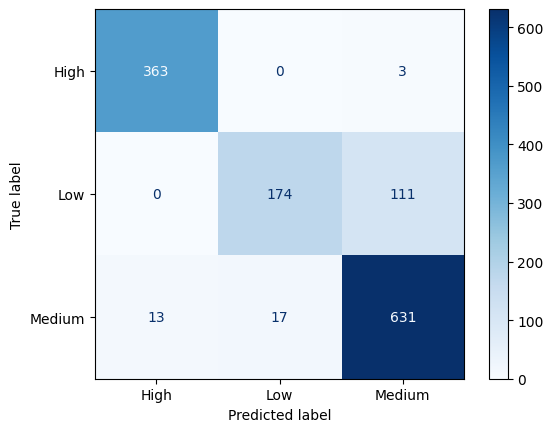

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train, cmap='Blues')
plt.show()

In [ ]:
# Veamos los rendimientos de nuestro modelo
train_report = classification_report(y_train, y_pred_train)
print("Train Report for Logistic Regression\n", train_report)

Train Report for Logistic Regression
               precision    recall  f1-score   support

        High       0.97      0.99      0.98       366
         Low       0.91      0.61      0.73       285
      Medium       0.85      0.95      0.90       661

    accuracy                           0.89      1312
   macro avg       0.91      0.85      0.87      1312
weighted avg       0.89      0.89      0.88      1312



###### **Evaluación**

Ahora veamos los resultados en el conjunto de test

In [ ]:
# Antes debemos aplicar la función preprocess y el pipe hace el resto
X_test, y_test = preprocess(test_data)

Total de filas duplicadas eliminadas: 0


In [ ]:
y_pred_test = pipe_svm.predict(X_test)
y_pred_test

array(['Medium', 'Medium', 'High', 'Medium', 'Low', 'Medium', 'Medium',
       'High', 'High', 'Medium', 'Medium', 'Medium', 'Low', 'Medium',
       'Medium', 'Medium', 'Medium', 'High', 'Low', 'Low', 'Medium',
       'High', 'High', 'High', 'Medium', 'Medium', 'Medium', 'Medium',
       'High', 'High', 'High', 'High', 'Medium', 'High', 'High', 'Medium',
       'Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'Low', 'Medium',
       'High', 'Medium', 'Medium', 'Medium', 'High', 'Medium', 'Medium',
       'Low', 'Low', 'Medium', 'Medium', 'High', 'Medium', 'Medium',
       'Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'Low', 'Medium',
       'High', 'Medium', 'Low', 'High', 'Medium', 'Medium', 'High',
       'High', 'High', 'High', 'Medium', 'Medium', 'Medium', 'Medium',
       'Low', 'High', 'High', 'High', 'High', 'Medium', 'Medium',
       'Medium', 'Medium', 'High', 'Medium', 'Medium', 'Medium', 'High',
       'Medium', 'Medium', 'Medium', 'High', 'Medium', 'Medium', 'High',
  

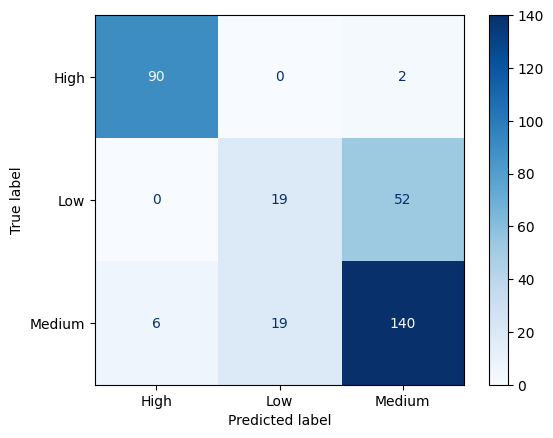

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, cmap='Blues')
plt.show()

In [ ]:
test_report = classification_report(y_test, y_pred_test)
print("Test Report for Logistic Regression\n", test_report)

Test Report for Logistic Regression
               precision    recall  f1-score   support

        High       0.94      0.98      0.96        92
         Low       0.50      0.27      0.35        71
      Medium       0.72      0.85      0.78       165

    accuracy                           0.76       328
   macro avg       0.72      0.70      0.70       328
weighted avg       0.73      0.76      0.74       328



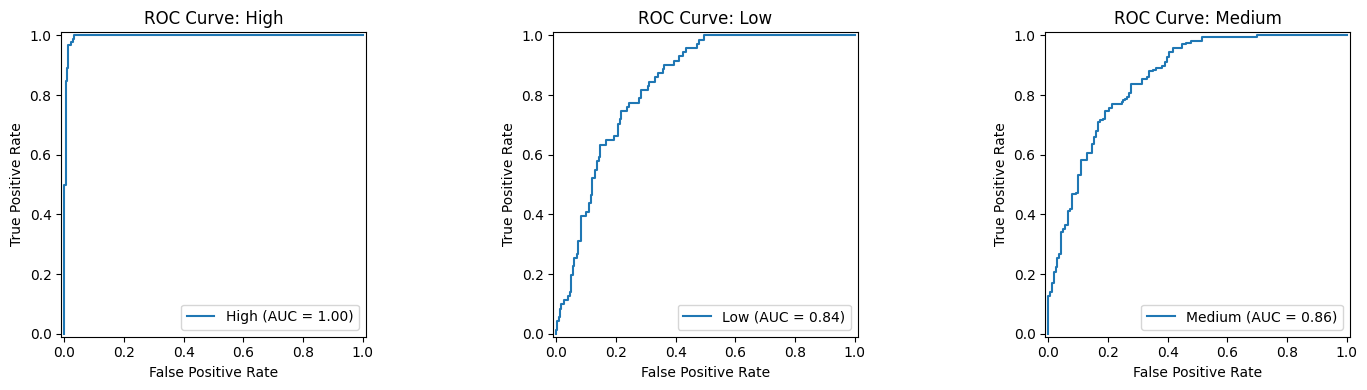

In [ ]:
# Obtener las predicciones
y_proba = pipe_svm.predict_proba(X_test)
classes = pipe_svm.classes_

# Binarizamos los labels
y_test_bin = label_binarize(y_test, classes=classes)

# Creamos las ROC por cada clase
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])

    display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc(fpr, tpr))
    display.plot(ax=axes[i], name=f'{class_label}')
    axes[i].set_title(f'ROC Curve: {class_label}')

plt.tight_layout()
plt.show()

##### **Modelo: Búsqueda de Hiperparámetros**

In [ ]:
# Traigamos el pipe nuevamente
estimators_svm = [
    ('transform', preprocessor),
    ('model', SVC(kernel='rbf', probability=True, random_state=71))
]

pipe_svm = Pipeline(estimators_svm)
pipe_svm

Pipeline(steps=[('transform',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7cbd1752fc50>),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x7cbd176d1220>)])),
                ('model', SVC(probability=True, random_state=71))])

In [ ]:
param_grid = {
    # Hiperparametros para el modelo
    'model__C': [0.1, 1, 10],
    'model__kernel': ['rbf', 'poly', 'linear'],
    'model__gamma': ['scale', 'auto', 0.001, 0.1],
    # Hiperparametros para el preprocesamiento
    'transform__num__scaler': [StandardScaler(), MinMaxScaler()],
    'transform__cat__imputer__strategy': ['most_frequent', 'constant'],
    'transform__cat__scaler': [OneHotEncoder(), OrdinalEncoder()]
}

In [ ]:
grid_search = GridSearchCV(pipe_svm, param_grid, verbose=2, scoring='precision_macro', cv=5, n_jobs=-1)

In [ ]:
%%time
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
CPU times: user 7.55 s, sys: 703 ms, total: 8.26 s
Wall time: 8min 27s


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('transform',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         <sklearn.compose._column_transformer.make_column_selector object at 0x7cbd1752fc50>),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('scaler',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        spa...
                                            random_state=71))]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10],
                         'model__gamma': ['scale', 'auto', 0.001, 0.1],
                         'model__kernel': ['rbf', 'poly', 'linear'],
                         'transform__cat__imputer__strategy': ['most_frequent',
                                                               'constant'],
                         'transform__cat__scaler': [OneHotEncoder(),
                                                    OrdinalEncoder()],
                         'transform__num__scaler': [StandardScaler(),
                                                    MinMaxScaler()]},
             scoring='precision_macro', verbose=2)

In [ ]:
pd.DataFrame(grid_search.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__C,param_model__gamma,param_model__kernel,param_transform__cat__imputer__strategy,param_transform__cat__scaler,param_transform__num__scaler,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.672844,0.009977,0.057038,0.000854,0.1,scale,rbf,most_frequent,OneHotEncoder(),StandardScaler(),"{'model__C': 0.1, 'model__gamma': 'scale', 'mo...",0.168568,0.167300,0.167939,0.167939,0.167939,0.167937,0.000401,228
1,0.585143,0.019774,0.061398,0.013121,0.1,scale,rbf,most_frequent,OneHotEncoder(),MinMaxScaler(),"{'model__C': 0.1, 'model__gamma': 'scale', 'mo...",0.505072,0.804794,0.479103,0.824512,0.453145,0.613325,0.165319,164
2,0.976844,0.179836,0.091951,0.021229,0.1,scale,rbf,most_frequent,OrdinalEncoder(),StandardScaler(),"{'model__C': 0.1, 'model__gamma': 'scale', 'mo...",0.168568,0.167300,0.167939,0.167939,0.167939,0.167937,0.000401,228
3,0.703789,0.111235,0.078453,0.027637,0.1,scale,rbf,most_frequent,OrdinalEncoder(),MinMaxScaler(),"{'model__C': 0.1, 'model__gamma': 'scale', 'mo...",0.509722,0.810034,0.484009,0.826444,0.456245,0.617291,0.165025,161
4,0.675139,0.017758,0.058033,0.001186,0.1,scale,rbf,constant,OneHotEncoder(),StandardScaler(),"{'model__C': 0.1, 'model__gamma': 'scale', 'mo...",0.168568,0.167300,0.167939,0.167939,0.167939,0.167937,0.000401,228
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,1.060134,0.337503,0.041021,0.012062,10.0,0.1,linear,most_frequent,OrdinalEncoder(),MinMaxScaler(),"{'model__C': 10, 'model__gamma': 0.1, 'model__...",0.168568,0.462704,0.167939,0.469185,0.167939,0.287267,0.145904,216
284,0.649011,0.113582,0.023586,0.000565,10.0,0.1,linear,constant,OneHotEncoder(),StandardScaler(),"{'model__C': 10, 'model__gamma': 0.1, 'model__...",0.928428,0.926149,0.933352,0.907296,0.930939,0.925233,0.009287,13
285,0.214266,0.017949,0.023717,0.000615,10.0,0.1,linear,constant,OneHotEncoder(),MinMaxScaler(),"{'model__C': 10, 'model__gamma': 0.1, 'model__...",0.926053,0.926149,0.935879,0.907296,0.937684,0.926612,0.010790,9
286,3.421225,0.536270,0.039658,0.002732,10.0,0.1,linear,constant,OrdinalEncoder(),StandardScaler(),"{'model__C': 10, 'model__gamma': 0.1, 'model__...",0.720537,0.700016,0.431416,0.379859,0.779118,0.602189,0.163386,169


In [ ]:
best_model = grid_search.best_estimator_
grid_search.best_params_

{'model__C': 1,
 'model__gamma': 'scale',
 'model__kernel': 'linear',
 'transform__cat__imputer__strategy': 'constant',
 'transform__cat__scaler': OneHotEncoder(),
 'transform__num__scaler': MinMaxScaler()}

In [ ]:
supp_vectors = best_model[1].support_vectors_
supp_ = best_model[1].support_
dual_coefs = best_model[1].dual_coef_

supp_vectors_df = pd.DataFrame(supp_vectors, columns=best_model[0].get_feature_names_out())
supp_vectors_df

,num__Building_Area_m2,num__Policy_Interventions,num__Embodied_Emissions_tCO2e,num__Operational_Emissions_tCO2e,num__Supply_Chain_Emission_Share_%,num__ReadyMix_Concrete_Emission_tCO2e,num__Electric_Power_Emission_tCO2e,num__Lighting_Fixture_Emission_tCO2e,num__Material_Reuse_%,num__Renewable_Energy_%,...,cat__Project_Type_Mid-rise,cat__Green_Certification_Level_Basic,cat__Green_Certification_Level_Gold,cat__Green_Certification_Level_Platinum,cat__Green_Certification_Level_Silver,cat__Green_Certification_Level_missing_value,cat__Lifecycle_Phase_Construction,cat__Lifecycle_Phase_End-of-life,cat__Lifecycle_Phase_Material Production,cat__Lifecycle_Phase_Operation
0,0.913077,0.25,0.753266,0.849907,0.512,0.987568,0.495117,0.704741,0.585170,0.941345,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.952760,0.50,0.907565,0.511251,0.122,0.861486,0.997686,0.417593,0.082164,0.423462,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.784980,0.50,0.888495,0.673756,0.762,0.052710,0.832327,0.990782,0.839679,0.698140,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.334122,0.50,0.254170,0.040858,0.956,0.882970,0.766341,0.269785,0.426854,0.497854,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.402180,0.25,0.974512,0.493315,0.652,0.420724,0.107555,0.035871,0.068136,0.163090,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,0.830266,0.25,0.869459,0.333979,0.544,0.077553,0.581816,0.034692,0.374749,0.015737,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
370,0.915596,0.00,0.996591,0.198969,0.336,0.774737,0.427390,0.516131,0.959920,0.379113,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
371,0.840907,0.25,0.320655,0.646350,0.678,0.918021,0.665764,0.683411,0.122244,0.882690,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
372,0.129948,0.50,0.693276,0.733974,0.930,0.765541,0.007458,0.925364,0.695391,0.889843,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [ ]:
y_pred_train_hip = best_model.predict(X_train)
y_pred_train_hip

array(['Medium', 'Low', 'High', ..., 'Low', 'Medium', 'Medium'],
      dtype=object)

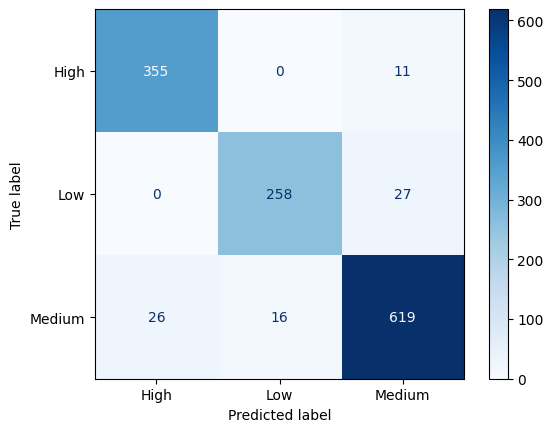

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_train, y_pred_train_hip, cmap='Blues')
plt.show()

In [ ]:
# Veamos los rendimientos de nuestro modelo
train_report = classification_report(y_train, y_pred_train_hip)
print("Train Report for Logistic Regression\n", train_report)

Train Report for Logistic Regression
               precision    recall  f1-score   support

        High       0.93      0.97      0.95       366
         Low       0.94      0.91      0.92       285
      Medium       0.94      0.94      0.94       661

    accuracy                           0.94      1312
   macro avg       0.94      0.94      0.94      1312
weighted avg       0.94      0.94      0.94      1312



###### **Evaluación**
Veamos los resultados con test de nuestro mejor modelo

In [ ]:
# Antes debemos aplicar la función preprocess y el pipe hace el resto
X_test, y_test = preprocess(test_data)

Total de filas duplicadas eliminadas: 0


In [ ]:
y_pred_test_hip = best_model.predict(X_test)
y_pred_test_hip

array(['Medium', 'Medium', 'High', 'Medium', 'Medium', 'Low', 'Medium',
       'High', 'High', 'Low', 'Medium', 'Medium', 'Low', 'Low', 'Low',
       'Low', 'Medium', 'High', 'Medium', 'Medium', 'Low', 'High', 'High',
       'High', 'Medium', 'Low', 'Medium', 'Medium', 'High', 'High',
       'High', 'High', 'Medium', 'High', 'High', 'Low', 'Medium',
       'Medium', 'Low', 'Low', 'Low', 'Medium', 'Medium', 'High',
       'Medium', 'Medium', 'Medium', 'High', 'Medium', 'Medium', 'Medium',
       'Low', 'Medium', 'Medium', 'High', 'Medium', 'Medium', 'Medium',
       'Low', 'Medium', 'Medium', 'Low', 'Low', 'Low', 'High', 'Medium',
       'Low', 'High', 'Medium', 'Medium', 'High', 'High', 'High', 'High',
       'Medium', 'Medium', 'Medium', 'Low', 'Low', 'High', 'High', 'High',
       'High', 'Medium', 'Medium', 'Low', 'Medium', 'High', 'Medium',
       'Low', 'Low', 'High', 'Medium', 'Low', 'Medium', 'High', 'Medium',
       'Medium', 'High', 'Low', 'Low', 'Medium', 'High', 'High', 'Med

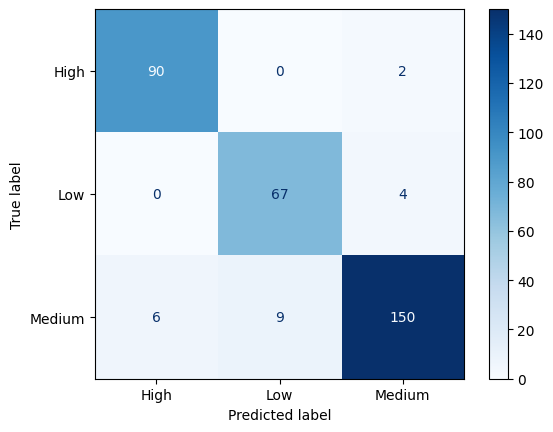

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test_hip, cmap='Blues')
plt.show()

In [ ]:
test_report = classification_report(y_test, y_pred_test_hip)
print("Test Report for Logistic Regression\n", test_report)

Test Report for Logistic Regression
               precision    recall  f1-score   support

        High       0.94      0.98      0.96        92
         Low       0.88      0.94      0.91        71
      Medium       0.96      0.91      0.93       165

    accuracy                           0.94       328
   macro avg       0.93      0.94      0.93       328
weighted avg       0.94      0.94      0.94       328



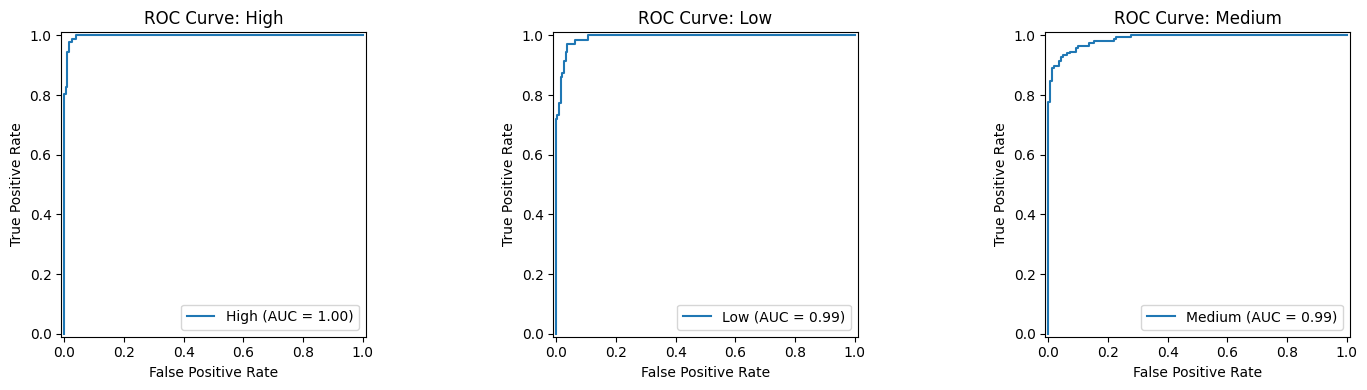

In [ ]:
# Obtener las predicciones
y_proba = best_model.predict_proba(X_test)
classes = best_model.classes_

# Binarizamos los labels
y_test_bin = label_binarize(y_test, classes=classes)

# Creamos las ROC por cada clase
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, class_label in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])

    display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc(fpr, tpr))
    display.plot(ax=axes[i], name=f'{class_label}')
    axes[i].set_title(f'ROC Curve: {class_label}')

plt.tight_layout()
plt.show()

### **3. Preguntas**

1. En este lab usamos `kernel = "rbf"`, existen otros kernels? Prueba otros kernels de manera inidivudal e identifica las diferencias.
2. Si en la SVC el parámetro probability cambia a False, ¿podrías ver la probabilidad de cada predicción? Cambia el código que sea necesario.
3. ¿Cómo se interpreta los AUC Scores del set de test para ambos modelos entrenados? ¿Cuáles son sus diferencias?